### Bonus Solution: Composing Kernels

/opt/homebrew/Caskroom/miniconda/base/envs/cs2109s-ay2526s2/lib/python3.12/site-packages/sklearn/utils/__init__.py:15: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.3)
  from scipy.sparse import issparse


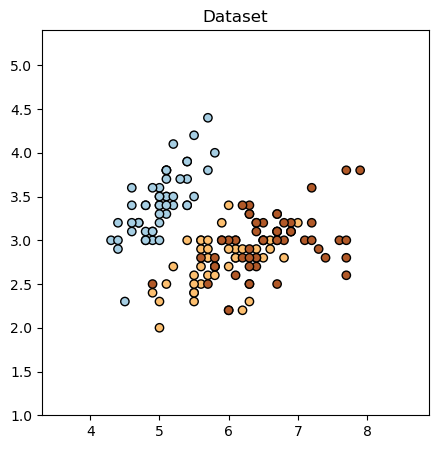

In [1]:
# Seting up the environment and importing necessary libraries

from sklearn.svm import SVC
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
import math

# Load dataset
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

# Adapted from https://www.kaggle.com/code/residentmario/kernels-and-support-vector-machine-regularization
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = (x_max / x_min)/100
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X_test = np.c_[xx.ravel(), yy.ravel()]

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, linewidth=1, edgecolor='black')
plt.xlim((x_min, x_max))
plt.ylim((y_min, y_max))
plt.title('Dataset')
plt.show()

For Task 1, we have two kernel functions

$$
K_1(u, v) = \phi_1(u) \cdot \phi_1(v), \quad
K_2(u, v) = \phi_2(u) \cdot \phi_2(v)
$$
Hence, 
$$
K_1(u, v) + K_2(u, v)
=
\begin{bmatrix}
\phi_1(u) \\
\phi_2(u)
\end{bmatrix}
\cdot
\begin{bmatrix}
\phi_1(v) \\
\phi_2(v)
\end{bmatrix}
$$

which means the addition of two kernel functions **essentially** concatenates the transformed features together. This can be implemented using torch.hstack.

In [2]:
def transform_add(X1, X2):
    return np.hstack([X1, X2])

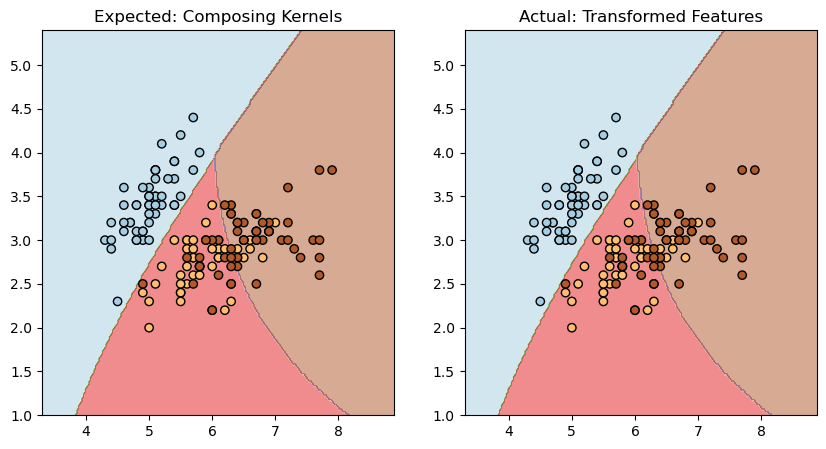

In [3]:
# Test case. Adds the kernels (u ⋅ v)^1 and (u ⋅ v)^2 together.

def my_add_kernel(U, V):
    return np.dot(U, V.T) ** 1 + np.dot(U, V.T) ** 2

def transform_K1(X):
    return X.copy()

def transform_K2(X):
    return np.stack([
        X[:, 0] * X[:, 0],
        math.sqrt(2) * X[:, 0] * X[:, 1],
        X[:, 1] * X[:, 1],
    ], axis=-1)

plt.subplots(1, 2, figsize=(10, 5))

svc = SVC(kernel=my_add_kernel).fit(X, y)
plt.subplot(1, 2, 1)
Z_correct = svc.predict(X_test)
Z_correct = Z_correct.reshape(xx.shape)
plt.contourf(xx, yy, Z_correct, cmap=plt.cm.Paired, alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, linewidth=1, edgecolor='black')
plt.title("Expected: Composing Kernels")

X_transformed = transform_add(transform_K1(X), transform_K2(X))
svc = SVC(kernel="linear").fit(X_transformed, y)
X_test_transformed = transform_add(transform_K1(X_test), transform_K2(X_test))
plt.subplot(1, 2, 2)
Z_test = svc.predict(X_test_transformed)
Z_test = Z_test.reshape(xx.shape)
plt.contourf(xx, yy, Z_test, cmap=plt.cm.Paired, alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, linewidth=1, edgecolor='black')
plt.title("Actual: Transformed Features")

assert np.all(Z_correct == Z_test), "Your SVM gives a different classification"

plt.show()

For Task 2, similarly, we get

$$
K_1(u, v) \times K_2(u, v)
= (\phi_1(u) \cdot \phi_1(v)) \times (\phi_2(u) \cdot \phi_2(v))
$$

$$
= \left( \sum_i \phi_1(u)_i \phi_1(v)_i \right)
\times
\left( \sum_j \phi_2(u)_j \phi_2(v)_j \right)
$$

$$
= \sum_{ij} \big( \phi_1(u)_i \phi_2(u)_j \big)
\times
\big( \phi_1(v)_i \phi_2(v)_j \big)
$$

Define another set of transformed features $\phi^*(u)$ that consists of all pairs of features $\phi_1(u)_i \phi_2(u)_j$, then

$$
K_1(u, v) \times K_2(u, v) = \phi^*(u) \cdot \phi^*(v)
$$

which means the product of two kernel functions takes the **pairwise product** of their transformed features.
The implementation can clearly be done using broadcasting. Don’t forget to reshape the features back to
a single dimension!

In [4]:
def transform_multiply(X1, X2):
    n = X1.shape[0]
    pairwise_prod = X1.reshape(n, -1, 1) * X2.reshape(n, 1, -1)
    return pairwise_prod.reshape(n, -1)

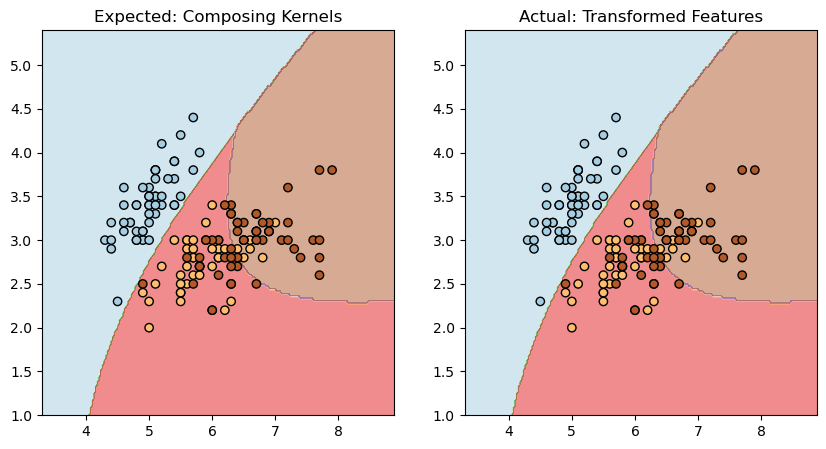

In [5]:
# Test case. Multiplies the kernels (u ⋅ v + 1)^1 and (u ⋅ v)^2 together.

def my_multiply_kernel(U, V):
    return ((np.dot(U, V.T) + 1) ** 1) * (np.dot(U, V.T) ** 2)

def transform_K1(X):
    return np.hstack([
        X,
        np.ones((X.shape[0], 1))
    ])

def transform_K2(X):
    return np.stack([
        X[:, 0] * X[:, 0],
        math.sqrt(2) * X[:, 0] * X[:, 1],
        X[:, 1] * X[:, 1],
    ], axis=-1)

plt.subplots(1, 2, figsize=(10, 5))

svc = SVC(kernel=my_multiply_kernel).fit(X, y)
plt.subplot(1, 2, 1)
Z_correct = svc.predict(X_test)
Z_correct = Z_correct.reshape(xx.shape)
plt.contourf(xx, yy, Z_correct, cmap=plt.cm.Paired, alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, linewidth=1, edgecolor='black')
plt.title("Expected: Composing Kernels")

X_transformed = transform_multiply(transform_K1(X), transform_K2(X))
svc = SVC(kernel="linear").fit(X_transformed, y)
X_test_transformed = transform_multiply(transform_K1(X_test), transform_K2(X_test))
plt.subplot(1, 2, 2)
Z_test = svc.predict(X_test_transformed)
Z_test = Z_test.reshape(xx.shape)
plt.contourf(xx, yy, Z_test, cmap=plt.cm.Paired, alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, linewidth=1, edgecolor='black')
plt.title("Actual: Transformed Features")

assert np.all(Z_correct == Z_test), "Your SVM gives a different classification"

plt.show()

Task 3 is open-ended. You can create many interesting kernels with just sums and products, especially if
involving the Gaussian kernel!